In [2]:
import json
import os
import subprocess

# Circuit compilation stuff 

def run_command(command):
    """Execute a shell command and return its output or raise an exception on error"""
    process = subprocess.Popen(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        shell=True
    )
    stdout, stderr = process.communicate()
    if process.returncode != 0:
        raise Exception(f"Command failed: {stderr.decode()}")
    return stdout.decode()

def compile_circuit(circuit_path, circuit_name):
    """Compile a Circom circuit to WASM and R1CS in the rappor_logic directory"""
    # Create output directory if it doesn't exist
    os.makedirs("build", exist_ok=True)
    
    # Compile with output to build directory
    command = f"circom {circuit_path} --output build -l ../circomlib --r1cs --wasm --sym --c"
    run_command(command)

    return f"build/{circuit_name}_js"

def generate_witness(js_dir, wasm_file, input_file, witness_file):
    """Generate witness for a circuit with the given input"""
    command = f"node {js_dir}/generate_witness.js {js_dir}/{wasm_file}.wasm {input_file} {witness_file}"
    return run_command(command)

def export_witness_to_json(witness_file, json_file="build/witness.json"):
    """Export a witness file to JSON format in the build directory"""
    # Make sure the output directory exists
    os.makedirs(os.path.dirname(json_file), exist_ok=True)
    
    run_command(f"snarkjs wtns export json {witness_file} {json_file}")
    with open(json_file, "r") as f:
        return json.load(f)

def extract_bits_from_witness(witness_data, start_idx, max_bits):
    """Extract bit values (0 or 1) from witness data"""
    bits = []
    for i in range(start_idx, len(witness_data)):
        if len(bits) < max_bits:
            if witness_data[i] in ['0', '1']:
                bits.append(int(witness_data[i]))
    return bits

compile_circuit("rappor_histogram_main.circom", "rappor_histogram_main")


'build/rappor_histogram_main_js'

In [3]:
import time
import random

def produce_rappor_response(value, debug_js, response_index):
    input_file = "debug_input.json"
    witness_file = "debug_witness.wtns"

    all_one_randomness = str(2**250 - 1)
    all_zero_randomness = 0

    rand1 = random.randint(0, 2**250)
    rand2 = random.randint(0, 2**250)

    input_data = { "p_randomness": str(rand1), 
                    "q_randomness": str(rand2), 
                    "new_value": str(value)}

    with open(input_file, "w") as f:
        json.dump(input_data, f)

    witness = generate_witness(debug_js, "rappor_histogram_main", input_file, witness_file)

    #     sym_file = "build/rappor_histogram_main.sym"
    #     response_index = 0

    #     if os.path.exists(sym_file):
    #         with open(sym_file, "r") as f:
    #             for line in f:
    #                 parts = line.strip().split(",")
    #                 if len(parts) >= 4:
    #                     idx = int(parts[0])
    #                     symbol = parts[3]
    #                     if "rappor_response" in symbol:
    #                         response_index = idx
    #     print(response_index)
    
    
    witness_data = export_witness_to_json(witness_file)
    rappor_response = int(witness_data[response_index]) 

    bit_length = 16
    bits = [int(b) for b in bin(rappor_response)[2:]]
    bits.reverse() 
    bits += [0] * (bit_length - len(bits))

    return bits

In [4]:
rappor_responses = []
debug_js = compile_circuit("rappor_histogram_main.circom", "rappor_histogram_main")
response_index = 1
start_time = time.time()
values = [2,3,4,5]
for i in range(0, 1250):
    for j in range(0, 4):
        new_rappor = produce_rappor_response(values[j], debug_js, response_index)
        rappor_responses.append(new_rappor)

end_time = time.time()  # End the timer
print(f"Execution time: {end_time - start_time:.2f} seconds")
        
# print(rappor_responses)

Execution time: 682.11 seconds


In [5]:
# Initialize a list of 0s with the same length as the vectors (16)
summed = [0] * 16

# Iterate over each vector
for vec in rappor_responses:
    # Add each bit to the corresponding position in the sum
    for i in range(16):
        summed[i] += vec[i]
        
print(summed)

[2473, 2408, 2511, 2542, 2763, 2546, 2431, 2792, 2502, 2468, 2463, 2812, 2836, 3444, 2460, 2779]


In [6]:
# Truly set estimation formula:
# t_{i} = (c_i - (p + 1/2fq - 1/2fp)N)/(1-f)(q-p)
# t_i = (c_i - pN/(q-p))
# p = 0.5, q = 0.75
# c_i : truly set count for bit i 
# N number of reports

falsely_set = (5000 * 0.5)
denominator = 0.75 - 0.5
normalized_bitcounts = []
for v in summed:
    normalized_bitcounts.append((v - falsely_set)/denominator)

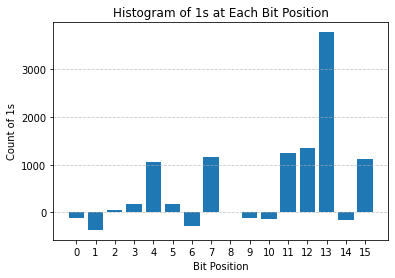

In [7]:
import matplotlib.pyplot as plt

def plot_bit_position_histogram(counts):
    positions = list(range(16))  # Bit positions from 0 to 15
    plt.bar(positions, counts)
    plt.xlabel('Bit Position')
    plt.ylabel('Count of 1s')
    plt.title('Histogram of 1s at Each Bit Position')
    plt.xticks(positions)
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.show()
    
plot_bit_position_histogram(normalized_bitcounts)

{0: [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0], 1: [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 2: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0], 3: [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0], 4: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1], 5: [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0], 6: [0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0], 7: [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]}
{0: -368.0, 1: 168.0, 2: 1248.0, 3: 1052.0, 4: 1116.0, 5: 1168.0, 6: -128.0, 7: -160.0}
[-368.0, 168.0, 1248.0, 1052.0, 1116.0, 1168.0, -128.0, -160.0]


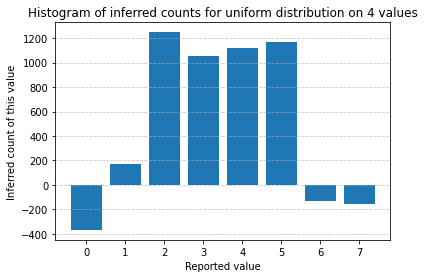

In [8]:
# generate a rappor response with no randomization to know the indices that need to be set.
def produce_correct_answers(value, debug_js, response_index):
    input_file = "debug_input.json"
    witness_file = "debug_witness.wtns"

    all_one_randomness = str(2**250 - 1)
    all_zero_randomness = str(0)


    input_data = { "p_randomness": all_one_randomness, 
                    "q_randomness": all_zero_randomness, 
                    "new_value": str(value)}

    with open(input_file, "w") as f:
        json.dump(input_data, f)

    witness = generate_witness(debug_js, "rappor_histogram_main", input_file, witness_file)
    
    witness_data = export_witness_to_json(witness_file)
    rappor_response = int(witness_data[response_index]) 

    bit_length = 16
    bits = [int(b) for b in bin(rappor_response)[2:]]
    bits.reverse() 
    bits += [0] * (bit_length - len(bits))

    return bits

correct_answer_bit_vectors = {}
for value in [0,1,2,3,4,5,6,7]:
    bitvec = produce_correct_answers(value, debug_js, response_index)
    correct_answer_bit_vectors[value] = bitvec
    
print(correct_answer_bit_vectors)

key_counts = {}
for key in correct_answer_bit_vectors:
    counts_for_key = []
    for index, value in enumerate(correct_answer_bit_vectors[key]):
        if value == 1:
            counts_for_key.append(normalized_bitcounts[index])
    key_counts[key] = min(counts_for_key)
print(key_counts)

sorted_key_counts = [key_counts[key] for key in sorted(key_counts)]
print(sorted_key_counts)
# plot_bit_position_histogram(sorted_key_counts)

positions = list(range(0,8))  # Bit positions from 0 to 10
plt.bar(positions, sorted_key_counts)
plt.xlabel('Reported value')
plt.ylabel('Inferred count of this value')
plt.title('Histogram of inferred counts for uniform distribution on 4 values')
plt.xticks(positions)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

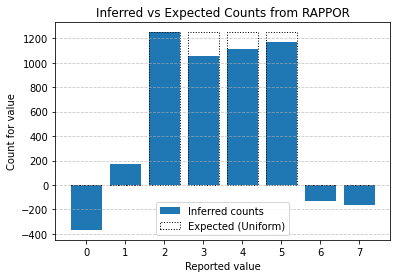

In [9]:
import matplotlib.pyplot as plt

positions = list(range(0, 8))
actual_counts = sorted_key_counts
reference_counts = [0, 0, 1250, 1250, 1250, 1250, 0, 0]

# Plot actual histogram bars
plt.bar(positions, actual_counts, label='Inferred counts')

# Plot reference bars as transparent with dotted edges only
plt.bar(
    positions,
    reference_counts,
    fill=False,              # no fill
    edgecolor='black',       # black edges
    linestyle=':',           # dotted line
    linewidth=1,             # thicker line for visibility
    label='Expected (Uniform)'
)

plt.xlabel('Reported value')
plt.ylabel('Count for value')
plt.title('Inferred vs Expected Counts from RAPPOR')
plt.xticks(positions)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.savefig("rappor_counts.pdf", format='pdf', bbox_inches='tight')
plt.show()
